## Análisis Predictivo

## 1. Decision Tree

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# 1. CARGAR DATOS
# ==============================
#url = "https://raw.githubusercontent.com/Javierff1985/TFM/main/Datos/ArchivoBeneficiariosInicial_.csv"

#url = "Documents/Documents/A_Maestria_Unir/TFM/ArchivoBeneficiariosInicial_limpio.csv"

df = pd.read_csv("ArchivoBeneficiariosInicial_limpio.csv", sep=';', encoding='latin1')
#df = pd.read_csv("archivo.csv")

print(df.shape)
print(df.head())
print(df.columns)

# ==============================
# 2. LIMPIEZA BÁSICA
# ==============================
#df = df.drop(columns=[
#    'ID',
#    'NOMBREEE',
#    'NOMBRESEDEEE',
#    'FECHAREGISRO',
#    'FECHANACIMIENTODDMMAAAA',
#    'CODIGODANEEE',
#    'CODIGODANESEDEEE',
#    'CENTROINTERES'
#], errors='ignore')

# Reemplazar nulos sin eliminar todas las filas
df = df.fillna('DESCONOCIDO')

# ==============================
# 3. VARIABLE OBJETIVO
# ==============================
objetivo = 'ELESTUDIANTEREQUIEREALIMENTACIONPRAASISTIRALCENTRODEINTERES'

y = df[objetivo]
X = df.drop(columns=[objetivo])

# ==============================
# 4. CODIFICAR VARIABLES CATEGÓRICAS
# ==============================
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# ==============================
# 5. DIVIDIR DATOS
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# 6. MODELO
# ==============================
modelo = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

# ==============================
# 7. EVALUACIÓN
# ==============================
y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

C:\Users\DGI-Campus.DESKTOP-45DMFEE\AppData\Local\Temp\ipykernel_8704\2236927323.py:14: DtypeWarning: Columns (26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ArchivoBeneficiariosInicial_limpio.csv", sep=';', encoding='latin1')


(532481, 28)
       ID  DIVIPOLAMUNICIPIO      DEPARTAMENTOMUNICIPIO   VEREDA URBABO-RURAL  \
0  221729              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
1  221730              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
2  221731              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
3  221732              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
4  221733              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   

  LINEADEPROGRAMA UNIVERSIDADEJECUTORA          RUTADEEXPERIENCIA  \
0            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
1            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
2            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
3            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
4            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   

  CODIGODANEEE                                           NOMBREEE  ...  \
0  2,47703E

## Evaluación del Modelo Decision Tree

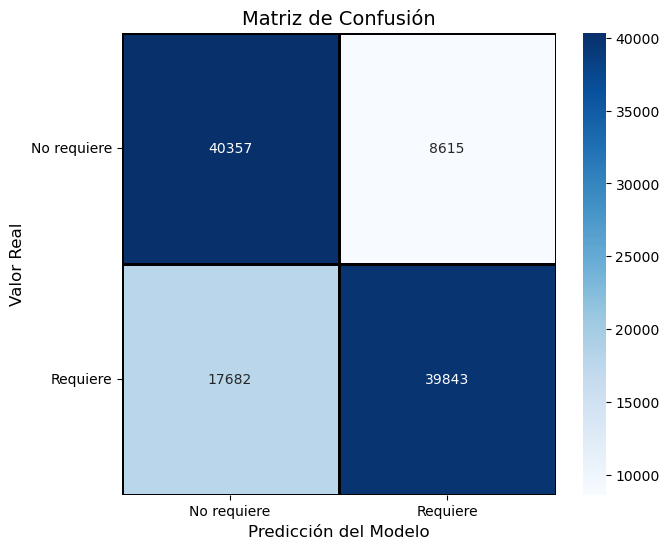

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# MATRIZ DE CONFUSIÓN
# ==============================
cm = confusion_matrix(y_test, y_pred)

# ==============================
# GRAFICAR
# ==============================
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black'
)

# Etiquetas
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.title('Matriz de Confusión', fontsize=14)

# Etiquetas de clases
plt.xticks([0.5,1.5], ['No requiere', 'Requiere'])
plt.yticks([0.5,1.5], ['No requiere', 'Requiere'], rotation=0)

plt.show()

### Los resultados demuestran que incluso utilizando un modelo sencillo como Árbol de Decisión, es posible generar predicciones útiles para apoyar la toma de decisiones y focalizar estrategias de intervención. 
### La importancia de esta matriz radica en que no solo muestra cuántas predicciones fueron correctas, sino también el tipo de error que comete el modelo, aspecto fundamental en escenarios de análisis social y toma de decisiones institucionales.

## 2. Random Forest

In [ ]:
# ==============================
# 1. IMPORTAR LIBRERÍAS
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 2. CARGAR DATOS
# ==============================
#url = "https://raw.githubusercontent.com/Javierff1985/TFM/main/Datos/ArchivoBeneficiariosInicial_.csv"

df = pd.read_csv("ArchivoBeneficiariosInicial_limpio.csv", sep=';', encoding='latin1')

#df = pd.read_csv(url, sep=';', encoding='latin1')

print("Dimensión del dataset:", df.shape)
print(df.head())
print(df.columns)

# ==============================
# 3. LIMPIEZA BÁSICA
# ==============================
df = df.drop(columns=[
    'ID',
    'NOMBREEE',
    'NOMBRESEDEEE',
    'FECHAREGISRO',
    'FECHANACIMIENTODDMMAAAA',
    'CODIGODANEEE',
    'CODIGODANESEDEEE',
    'CENTROINTERES'
], errors='ignore')

# Reemplazar valores nulos
df = df.fillna('DESCONOCIDO')

# ==============================
# 4. VARIABLE OBJETIVO
# ==============================
objetivo = 'ELESTUDIANTEREQUIERETRANSPORTEPARAASISTERALCENTRODEINTERES'

y = df[objetivo]
X = df.drop(columns=[objetivo])

print("\nDistribución de la variable objetivo:")
print(y.value_counts())

# ==============================
# 5. CODIFICAR VARIABLES CATEGÓRICAS
# ==============================
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# ==============================
# 6. DIVISIÓN TRAIN / TEST
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# 7. MODELO RANDOM FOREST
# ==============================
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

modelo.fit(X_train, y_train)

# ==============================
# 8. PREDICCIONES
# ==============================
y_pred = modelo.predict(X_test)


# ==============================
# 9. EVALUACIÓN DEL MODELO
# ==============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

C:\Users\DGI-Campus.DESKTOP-45DMFEE\AppData\Local\Temp\ipykernel_8704\3945553673.py:18: DtypeWarning: Columns (26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ArchivoBeneficiariosInicial_limpio.csv", sep=';', encoding='latin1')


Dimensión del dataset: (532481, 28)
       ID  DIVIPOLAMUNICIPIO      DEPARTAMENTOMUNICIPIO   VEREDA URBABO-RURAL  \
0  221729              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
1  221730              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
2  221731              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
3  221732              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   
4  221733              47703  47703-MAGDALENA-SAN ZENON  JANEIRO        RURAL   

  LINEADEPROGRAMA UNIVERSIDADEJECUTORA          RUTADEEXPERIENCIA  \
0            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
1            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
2            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
3            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   
4            PSCP           UATLANTICO  MUSICAS VOCALES Y CORALES   

  CODIGODANEEE                                           NOMBR

## Evaluación del Modelo Random Forest

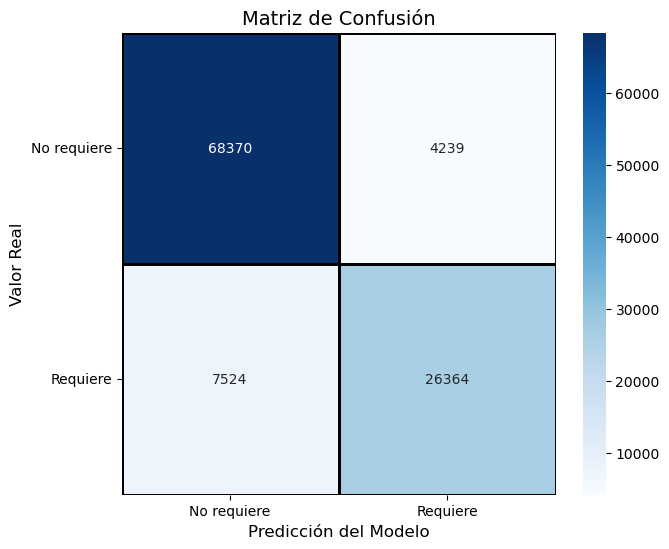

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# MATRIZ DE CONFUSIÓN
# ==============================
cm = confusion_matrix(y_test, y_pred)

# ==============================
# GRAFICAR
# ==============================
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black'
)

# Etiquetas
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.title('Matriz de Confusión', fontsize=14)

# Etiquetas de clases
plt.xticks([0.5,1.5], ['No requiere', 'Requiere'])
plt.yticks([0.5,1.5], ['No requiere', 'Requiere'], rotation=0)

plt.show()

### Se aplicó un modelo Random Forest para predecir si un estudiante requiere transporte para asistir al centro de interés. Este modelo combina múltiples árboles de decisión, lo que permite obtener predicciones más robustas.